# Anexo Técnico — Análisis del Caso 2: Costos Médicos

**Asignatura:** SCY1102 – Gestión de Proyectos de Datos
**Evaluación:** EP1 (Encargo) + EP2 (Presentación)
**Caso asignado:** 2 — Salud: Costos Médicos y Bienestar del Paciente
**Dataset:** `insurance.csv` (1.338 afiliados, 7 variables)
**Integrantes:** Diego Medina · Ignacio Arriagada · Javier Tapia · Pedro Ponce  
**Institución:** Duoc UC · Ingeniería en Ciencia de Datos · 2026

---

## Objetivo del notebook

Este notebook respalda **con evidencia estadística** cada afirmación cuantitativa presentada en el informe y en la presentación:

| Sección | Respalda |
|---|---|
| §1 Carga y calidad | *"1.338 registros, 7 variables, 0 nulos"* |
| §2 Distribuciones | Composición del dataset (sexo, región, tabaquismo, edad, IMC) |
| §3 Costos por grupo | *"Fumadores pagan 3,8× más"*, *"southeast concentra mayor costo"* |
| §4 Interacción tabaquismo × IMC | *"Fumador+obeso = US$ 41.693"* — hallazgo estrella |
| §5 Sesgos cuantificados | *"20 casos con IMC bajo (1,5 %)"*, *"20,5 % fumadores"* |
| §6 Correlaciones | *"age r=0,30, bmi r=0,20, children r=0,07"* |
| §7 Regresión lineal | Modelo base con `statsmodels.OLS` — muestra el peso real de cada variable |
| §8 Análisis del subgrupo crítico | *"12 % del gasto lo generan 3,8 % de los afiliados"* |
| §9 Conclusiones | Validación final de las recomendaciones del informe |

> Reproducibilidad: para ejecutar este notebook, coloca `insurance.csv` en la misma carpeta que este archivo `.ipynb` o ajusta la ruta en la sección §1.

## 1. Carga del dataset y verificación de calidad

Aquí verificamos las afirmaciones del informe: *1.338 registros, 7 variables, 0 nulos, 1 duplicado*.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# Configuración estética
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

# Paleta corporativa del informe
COL_PRIMARY = '#1f4e79'
COL_ACCENT = '#e67e22'
COL_MUTED = '#a6b1c2'
COL_BAD = '#c0392b'
COL_OK = '#2e8b57'

# Cargar dataset
df = pd.read_csv('insurance.csv')
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]} → {list(df.columns)}')
df.head()

Filas: 1338
Columnas: 7 → ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
# Tipos de datos, valores nulos y duplicados
print('Tipos de datos:')
print(df.dtypes)
print()
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print(f'Filas duplicadas: {df.duplicated().sum()}')
print()
print('Resumen estadístico:')
df.describe(include='all').round(2)

Tipos de datos:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Valores nulos totales: 0
Filas duplicadas: 1

Resumen estadístico:


,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


## 2. Distribuciones univariadas

Composición del dataset por variables categóricas y numéricas — sustento de la sección *Contexto* de la presentación y de los sesgos identificados en el informe.

In [3]:
# Distribuciones categóricas
for col in ['sex', 'smoker', 'region']:
    vc = df[col].value_counts()
    print(f'\n{col.upper()}:')
    for k, v in vc.items():
        print(f'  {k:<12} {v:>4}  ({v/len(df)*100:.1f}%)')


SEX:
  male          676  (50.5%)
  female        662  (49.5%)

SMOKER:
  no           1064  (79.5%)
  yes           274  (20.5%)

REGION:
  southeast     364  (27.2%)
  southwest     325  (24.3%)
  northwest     325  (24.3%)
  northeast     324  (24.2%)


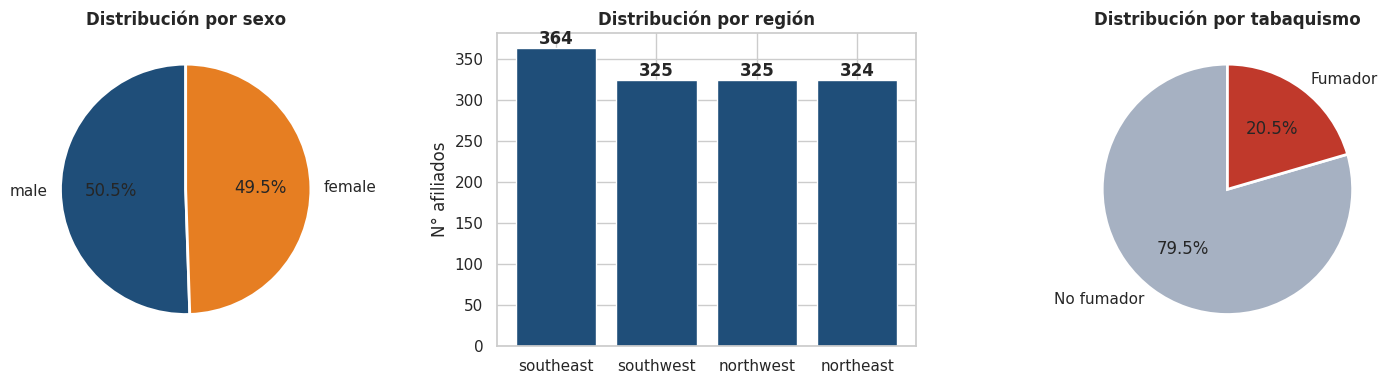

In [4]:
# Gráfico de composición (sexo, región, tabaquismo)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Sexo
sex_c = df['sex'].value_counts()
axes[0].pie(sex_c.values, labels=sex_c.index, autopct='%1.1f%%',
            colors=[COL_PRIMARY, COL_ACCENT], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribución por sexo', fontweight='bold')

# Región
reg_c = df['region'].value_counts()
axes[1].bar(reg_c.index, reg_c.values, color=COL_PRIMARY, edgecolor='white')
axes[1].set_title('Distribución por región', fontweight='bold')
axes[1].set_ylabel('N° afiliados')
for i, v in enumerate(reg_c.values):
    axes[1].text(i, v+5, str(v), ha='center', fontweight='bold')

# Tabaquismo
sm_c = df['smoker'].value_counts()
axes[2].pie(sm_c.values, labels=['No fumador','Fumador'], autopct='%1.1f%%',
            colors=[COL_MUTED, COL_BAD], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Distribución por tabaquismo', fontweight='bold')

plt.tight_layout()
plt.show()

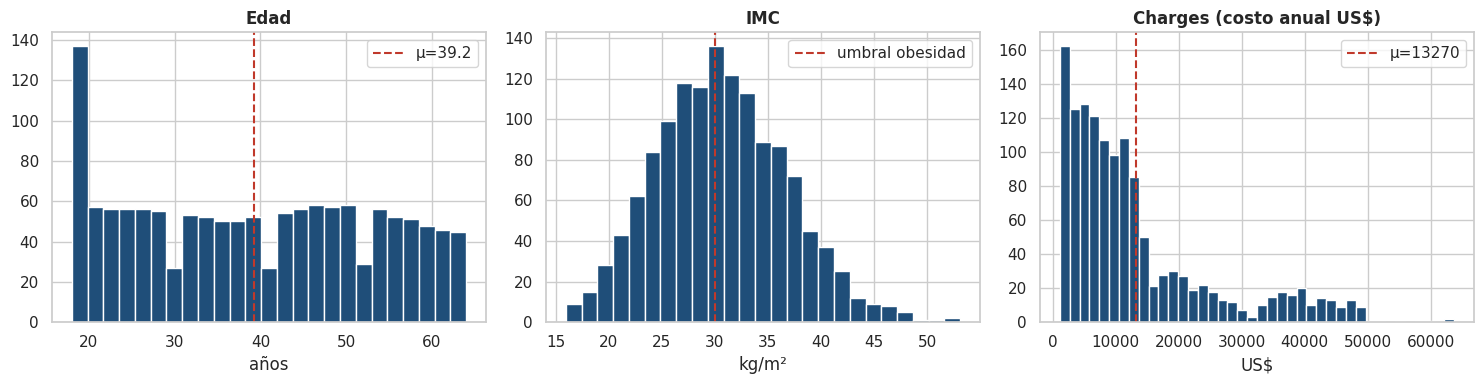

Charges: media US$ 13,270 | mediana US$ 9,382
La media > mediana indica sesgo positivo (cola larga hacia gastos altos).


In [5]:
# Distribuciones numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['age'], bins=25, color=COL_PRIMARY, edgecolor='white')
axes[0].set_title('Edad', fontweight='bold'); axes[0].set_xlabel('años')
axes[0].axvline(df['age'].mean(), color=COL_BAD, linestyle='--',
                label=f'μ={df.age.mean():.1f}')
axes[0].legend()

axes[1].hist(df['bmi'], bins=25, color=COL_PRIMARY, edgecolor='white')
axes[1].set_title('IMC', fontweight='bold'); axes[1].set_xlabel('kg/m²')
axes[1].axvline(30, color=COL_BAD, linestyle='--', label='umbral obesidad')
axes[1].legend()

axes[2].hist(df['charges'], bins=40, color=COL_PRIMARY, edgecolor='white')
axes[2].set_title('Charges (costo anual US$)', fontweight='bold')
axes[2].set_xlabel('US$')
axes[2].axvline(df['charges'].mean(), color=COL_BAD, linestyle='--',
                label=f'μ={df.charges.mean():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Charges: media US$ {df.charges.mean():,.0f} | mediana US$ {df.charges.median():,.0f}')
print(f'La media > mediana indica sesgo positivo (cola larga hacia gastos altos).')

## 3. Costo promedio por grupo — respaldo de los hallazgos del informe

### 3.1 Fumadores vs no fumadores

> *"Fumadores pagan 3,8× lo que pagan no fumadores"* — hallazgo central del §1 del encargo.

In [6]:
smoker_stats = df.groupby('smoker')['charges'].agg(['mean','median','std','count']).round(0)
smoker_stats.columns = ['Media US$','Mediana US$','Desv. estándar','N']
print(smoker_stats.to_string())

ratio = smoker_stats.loc['yes','Media US$'] / smoker_stats.loc['no','Media US$']
print(f'\n>>> Los fumadores pagan en promedio {ratio:.2f}× lo que pagan los no fumadores <<<')

        Media US$  Mediana US$  Desv. estándar     N
smoker                                              
no         8434.0       7345.0          5994.0  1064
yes       32050.0      34456.0         11542.0   274

>>> Los fumadores pagan en promedio 3.80× lo que pagan los no fumadores <<<


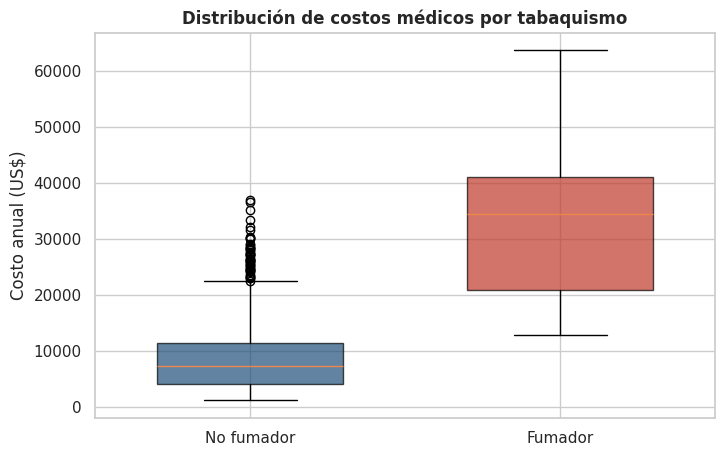

In [7]:
# Boxplot fumador vs no fumador
fig, ax = plt.subplots(figsize=(8, 5))
data = [df[df.smoker=='no']['charges'], df[df.smoker=='yes']['charges']]
bp = ax.boxplot(data, tick_labels=['No fumador','Fumador'],
                patch_artist=True, widths=0.6)
for patch, c in zip(bp['boxes'], [COL_PRIMARY, COL_BAD]):
    patch.set_facecolor(c); patch.set_alpha(0.7)
ax.set_ylabel('Costo anual (US$)')
ax.set_title('Distribución de costos médicos por tabaquismo', fontweight='bold')
plt.show()

### 3.2 Costo por región

> *"Southeast concentra el mayor costo promedio (US$ 14.735)"* — respaldo del análisis geográfico.

In [8]:
region_stats = df.groupby('region')['charges'].agg(['mean','median','count']).round(0)
region_stats.columns = ['Media US$','Mediana US$','N']
print(region_stats.sort_values('Media US$', ascending=False).to_string())

           Media US$  Mediana US$    N
region                                
southeast    14735.0       9294.0  364
northeast    13406.0      10058.0  324
northwest    12418.0       8966.0  325
southwest    12347.0       8799.0  325


### 3.3 Costo por rango de edad

> *"18-29 = US$ 9.182 → 60+ = US$ 21.248 (2,3×)"* — respaldo de la relación edad-costo.

In [9]:
df['grupo_edad'] = pd.cut(df['age'], bins=[17,29,39,49,59,70],
                          labels=['18-29','30-39','40-49','50-59','60+'])
edad_stats = df.groupby('grupo_edad', observed=True)['charges'].agg(['mean','median','count']).round(0)
edad_stats.columns = ['Media US$','Mediana US$','N']
print(edad_stats.to_string())
print(f'\nRatio 60+ vs 18-29: {edad_stats.loc["60+","Media US$"] / edad_stats.loc["18-29","Media US$"]:.2f}×')

            Media US$  Mediana US$    N
grupo_edad                             
18-29          9182.0       3214.0  417
30-39         11739.0       6082.0  257
40-49         14399.0       8606.0  279
50-59         16495.0      11730.0  271
60+           21248.0      14255.0  114

Ratio 60+ vs 18-29: 2.31×


## 4. Interacción tabaquismo × IMC — el hallazgo estrella

> *"Fumador + obeso = US$ 41.693 promedio anual, 4,71× un no fumador obeso"* — este es el hallazgo que estructura la presentación (slide 3) y la recomendación del informe.

In [10]:
df['imc_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                       labels=['bajo','normal','sobrepeso','obeso'])

# Tabla cruzada
interaccion = df.groupby(['smoker','imc_cat'], observed=True)['charges'].agg(['mean','count']).round(0)
print('Costo promedio y N por combinación tabaquismo × IMC:')
print(interaccion.to_string())

# Ratio fumador/no fumador dentro de cada categoría IMC
print('\nRatio Fumador/No fumador por IMC:')
pivot = df.groupby(['smoker','imc_cat'], observed=True)['charges'].mean().unstack()
for c in pivot.columns:
    r = pivot.loc['yes', c] / pivot.loc['no', c]
    print(f'  IMC {c:<10}: {r:.2f}×')

Costo promedio y N por combinación tabaquismo × IMC:
                     mean  count
smoker imc_cat                  
no     bajo        5485.0     16
       normal      7735.0    176
       sobrepeso   8226.0    311
       obeso       8853.0    561
yes    bajo       18810.0      5
       normal     19942.0     50
       sobrepeso  22491.0     75
       obeso      41693.0    144

Ratio Fumador/No fumador por IMC:
  IMC bajo      : 3.43×
  IMC normal    : 2.58×
  IMC sobrepeso : 2.73×
  IMC obeso     : 4.71×


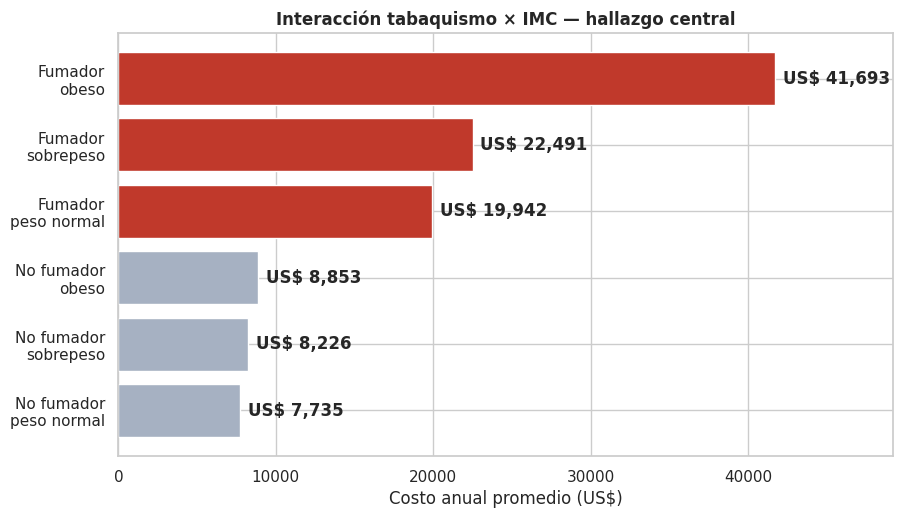

In [11]:
# Gráfico de barras — interacción
fig, ax = plt.subplots(figsize=(10, 5.5))
grupos = ['No fumador\npeso normal','No fumador\nsobrepeso','No fumador\nobeso',
          'Fumador\npeso normal','Fumador\nsobrepeso','Fumador\nobeso']
def mean_of(sm, cat):
    return df[(df.smoker==sm) & (df.imc_cat==cat)]['charges'].mean()
vals = [mean_of('no','normal'), mean_of('no','sobrepeso'), mean_of('no','obeso'),
        mean_of('yes','normal'), mean_of('yes','sobrepeso'), mean_of('yes','obeso')]
colors = [COL_MUTED]*3 + [COL_BAD]*3
bars = ax.barh(grupos, vals, color=colors, edgecolor='white')
for b, v in zip(bars, vals):
    ax.text(v + 500, b.get_y()+b.get_height()/2, f'US$ {v:,.0f}',
            va='center', fontweight='bold')
ax.set_xlabel('Costo anual promedio (US$)')
ax.set_title('Interacción tabaquismo × IMC — hallazgo central', fontweight='bold')
ax.set_xlim(0, max(vals)*1.18)
plt.show()

## 5. Sesgos cuantificados en los datos

Cada afirmación del §2.1 del informe sobre sesgos debe estar respaldada por un número. Aquí los verificamos uno por uno.

In [12]:
print('SESGOS CUANTIFICADOS EN EL DATASET')
print('=' * 55)

# Sesgo 1: subrepresentación IMC bajo
n_bajo = (df.bmi < 18.5).sum()
print(f'\n[Sesgo IMC bajo]')
print(f'  Personas con IMC < 18,5: {n_bajo} ({n_bajo/len(df)*100:.1f}%)')
print(f'  Implicancia: predicciones sobre bajo peso son estadísticamente débiles.')

# Sesgo 2: fumadores minoría
n_fum = (df.smoker=='yes').sum()
print(f'\n[Sesgo tabaquismo]')
print(f'  Fumadores: {n_fum} ({n_fum/len(df)*100:.1f}%)')
print(f'  La minoría genera la varianza que domina el modelo.')

# Sesgo 3: género binario
print(f'\n[Sesgo género]')
print(f'  Categorías de sexo: {list(df.sex.unique())}')
print(f'  Solo dos categorías → excluye personas no binarias/trans.')

# Sesgo 4: geográfico (regiones EE.UU.)
print(f'\n[Sesgo geográfico]')
print(f'  Regiones: {list(df.region.unique())}')
print(f'  Son regiones de EE.UU., no representan al mercado chileno.')

# Sesgo 5: variables omitidas
print(f'\n[Variables omitidas]')
print(f'  No hay: ingreso, educación, ocupación, etnia, tipo de plan.')
print(f'  La variable REGIÓN podría actuar como proxy socioeconómico.')

SESGOS CUANTIFICADOS EN EL DATASET

[Sesgo IMC bajo]
  Personas con IMC < 18,5: 20 (1.5%)
  Implicancia: predicciones sobre bajo peso son estadísticamente débiles.

[Sesgo tabaquismo]
  Fumadores: 274 (20.5%)
  La minoría genera la varianza que domina el modelo.

[Sesgo género]
  Categorías de sexo: ['female', 'male']
  Solo dos categorías → excluye personas no binarias/trans.

[Sesgo geográfico]
  Regiones: ['southwest', 'southeast', 'northwest', 'northeast']
  Son regiones de EE.UU., no representan al mercado chileno.

[Variables omitidas]
  No hay: ingreso, educación, ocupación, etnia, tipo de plan.
  La variable REGIÓN podría actuar como proxy socioeconómico.


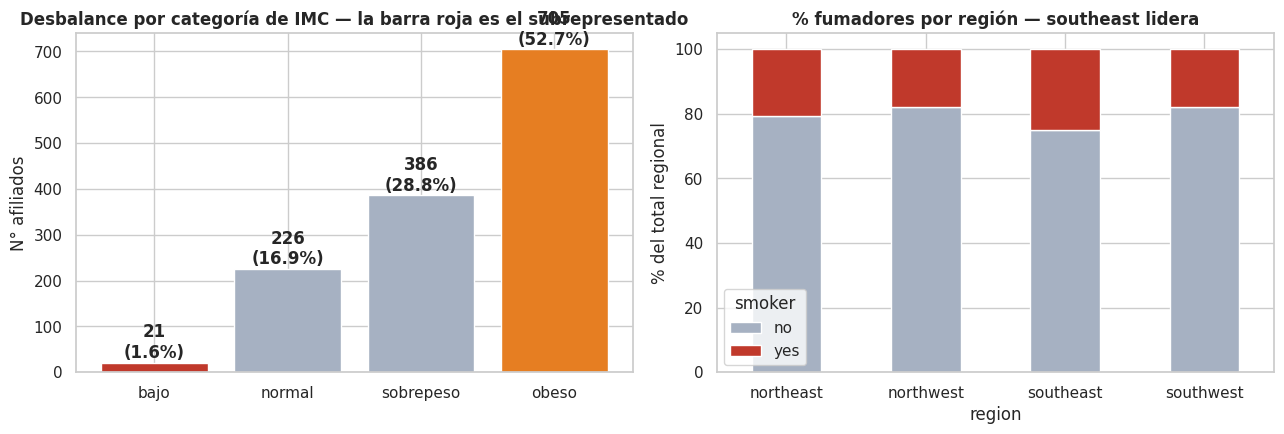

% de fumadores por región:
region
northeast    20.7
northwest    17.8
southeast    25.0
southwest    17.8


In [13]:
# Visualización de los desbalances
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# IMC en categorías
imc_c = df['imc_cat'].value_counts().sort_index()
colors_imc = [COL_BAD, COL_MUTED, COL_MUTED, COL_ACCENT]
bars = axes[0].bar(imc_c.index.astype(str), imc_c.values, color=colors_imc, edgecolor='white')
for b, v in zip(bars, imc_c.values):
    axes[0].text(b.get_x()+b.get_width()/2, v+10, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title('Desbalance por categoría de IMC — la barra roja es el subrepresentado', fontweight='bold')
axes[0].set_ylabel('N° afiliados')

# Fumador por región
smoker_region = pd.crosstab(df.region, df.smoker, normalize='index')*100
smoker_region.plot(kind='bar', stacked=True, ax=axes[1],
                   color=[COL_MUTED, COL_BAD], edgecolor='white')
axes[1].set_title('% fumadores por región — southeast lidera', fontweight='bold')
axes[1].set_ylabel('% del total regional')
axes[1].legend(title='smoker')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Southeast concentra la mayor tasa de fumadores
print('% de fumadores por región:')
print((df.groupby('region').smoker.apply(lambda s: (s=='yes').mean()*100).round(1)).to_string())

## 6. Correlaciones numéricas con charges

> *"age r=0,30, bmi r=0,20, children r=0,07"* — respaldo del análisis correlacional.

Matriz de correlación de Pearson:
            age    bmi  children  charges
age       1.000  0.109     0.042    0.299
bmi       0.109  1.000     0.013    0.198
children  0.042  0.013     1.000    0.068
charges   0.299  0.198     0.068    1.000


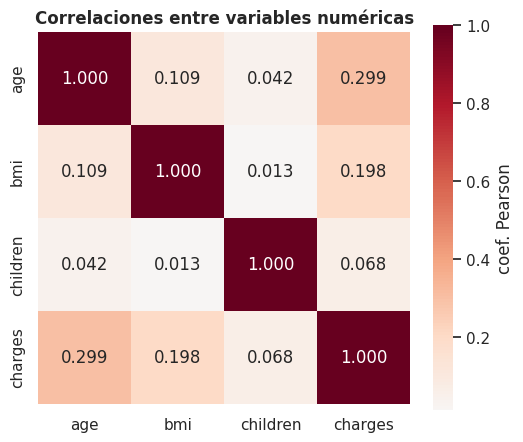


Correlaciones lineales con charges:
  age       : r = 0.299
  bmi       : r = 0.198
  children  : r = 0.068

Interpretación: ninguna variable numérica sola explica bien charges.
El poder predictivo real está en smoker (variable categórica).


In [14]:
# Correlación numérica
num_cols = ['age','bmi','children','charges']
corr = df[num_cols].corr()
print('Matriz de correlación de Pearson:')
print(corr.round(3).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label':'coef. Pearson'}, ax=ax)
ax.set_title('Correlaciones entre variables numéricas', fontweight='bold')
plt.show()

print(f'\nCorrelaciones lineales con charges:')
for c in ['age','bmi','children']:
    print(f'  {c:<10}: r = {corr.loc[c,"charges"]:.3f}')
print('\nInterpretación: ninguna variable numérica sola explica bien charges.')
print('El poder predictivo real está en smoker (variable categórica).')

## 7. Regresión lineal múltiple (`statsmodels.OLS`)

Modelo base para cuantificar el aporte real de cada variable a `charges`. Esto respalda la afirmación del informe de que el modelo es viable pero requiere salvaguardas.

In [15]:
# Modelo OLS con variables categóricas
modelo = ols('charges ~ age + bmi + children + C(sex) + C(smoker) + C(region)',
             data=df).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:58:01   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -1.19

In [16]:
# Interpretación de coeficientes
print('INTERPRETACIÓN DE COEFICIENTES (impacto sobre charges en US$)')
print('=' * 60)
coefs = modelo.params
pvals = modelo.pvalues
for var, coef in coefs.items():
    signif = '***' if pvals[var] < 0.001 else '**' if pvals[var] < 0.01 else '*' if pvals[var] < 0.05 else ' '
    print(f'  {var:<25} {coef:>+12,.2f}  {signif} (p={pvals[var]:.4f})')

print(f'\nR² ajustado: {modelo.rsquared_adj:.4f}')
print(f'\n>>> Efecto ser FUMADOR: +US$ {coefs["C(smoker)[T.yes]"]:,.0f} anuales (variable dominante) <<<')
print(f'>>> Cada año adicional de edad: +US$ {coefs["age"]:,.0f} <<<')
print(f'>>> Cada punto de IMC adicional: +US$ {coefs["bmi"]:,.0f} <<<')

INTERPRETACIÓN DE COEFICIENTES (impacto sobre charges en US$)
  Intercept                   -11,938.54  *** (p=0.0000)
  C(sex)[T.male]                 -131.31    (p=0.6933)
  C(smoker)[T.yes]            +23,848.53  *** (p=0.0000)
  C(region)[T.northwest]         -352.96    (p=0.4588)
  C(region)[T.southeast]       -1,035.02  * (p=0.0308)
  C(region)[T.southwest]         -960.05  * (p=0.0448)
  age                            +256.86  *** (p=0.0000)
  bmi                            +339.19  *** (p=0.0000)
  children                       +475.50  *** (p=0.0006)

R² ajustado: 0.7494

>>> Efecto ser FUMADOR: +US$ 23,849 anuales (variable dominante) <<<
>>> Cada año adicional de edad: +US$ 257 <<<
>>> Cada punto de IMC adicional: +US$ 339 <<<


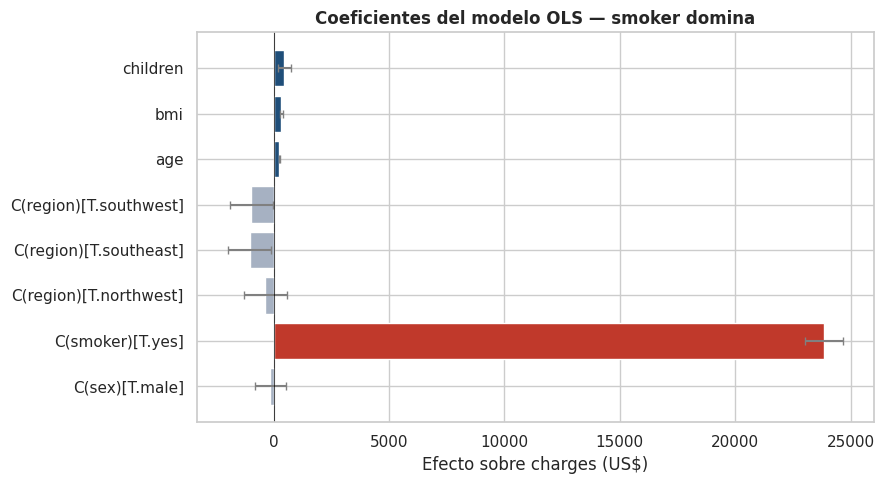

In [17]:
# Gráfico de coeficientes con intervalo de confianza
fig, ax = plt.subplots(figsize=(9, 5))
coefs_plot = modelo.params.drop('Intercept')
ci = modelo.conf_int().drop('Intercept')
ci.columns = ['low','high']
err = [(coefs_plot - ci['low']).values, (ci['high'] - coefs_plot).values]
colors_bar = [COL_BAD if v > 5000 else COL_PRIMARY if v > 0 else COL_MUTED for v in coefs_plot.values]
ax.barh(coefs_plot.index, coefs_plot.values, xerr=err, color=colors_bar,
        edgecolor='white', error_kw=dict(ecolor='gray', capsize=3))
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Efecto sobre charges (US$)')
ax.set_title('Coeficientes del modelo OLS — smoker domina', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Análisis del subgrupo crítico (fumador + obeso)

> *"10,8 % de los afiliados generan 33,8 % del gasto total"* — respaldo directo de la recomendación del informe de focalizar prevención en este subgrupo.

In [18]:
# Definir subgrupo
df['critico'] = (df.smoker=='yes') & (df.imc_cat=='obeso')

# Métricas del subgrupo
n_crit = df.critico.sum()
gasto_crit = df.loc[df.critico, 'charges'].sum()
gasto_total = df['charges'].sum()

pct_afiliados = n_crit / len(df) * 100
pct_gasto = gasto_crit / gasto_total * 100

print(f'Subgrupo crítico: fumador + obeso')
print(f'  Personas: {n_crit} de {len(df)}  →  {pct_afiliados:.2f}% de los afiliados')
print(f'  Gasto anual del subgrupo: US$ {gasto_crit:,.0f}')
print(f'  Gasto anual total: US$ {gasto_total:,.0f}')
print(f'  Participación del subgrupo en el gasto: {pct_gasto:.2f}%')
print(f'\n>>> {pct_afiliados:.1f}% de la población genera {pct_gasto:.1f}% del gasto <<<')
print(f'>>> Ratio de concentración: {pct_gasto/pct_afiliados:.1f}× <<<')

# Simulación: si prevención reduce 20% el gasto del subgrupo → cuánto se ahorra
ahorro_20 = gasto_crit * 0.20
print(f'\nSimulación: si un programa preventivo redujera 20% el gasto del subgrupo:')
print(f'  Ahorro anual estimado: US$ {ahorro_20:,.0f}')
print(f'  Costo Alternativa A del informe: US$ 54.000')
print(f'  ROI del programa: {ahorro_20/54000:.1f}×')

Subgrupo crítico: fumador + obeso
  Personas: 144 de 1338  →  10.76% de los afiliados
  Gasto anual del subgrupo: US$ 6,003,764
  Gasto anual total: US$ 17,755,825
  Participación del subgrupo en el gasto: 33.81%

>>> 10.8% de la población genera 33.8% del gasto <<<
>>> Ratio de concentración: 3.1× <<<

Simulación: si un programa preventivo redujera 20% el gasto del subgrupo:
  Ahorro anual estimado: US$ 1,200,753
  Costo Alternativa A del informe: US$ 54.000
  ROI del programa: 22.2×


### 8.1 Análisis de sensibilidad del ROI

El ROI depende críticamente de un supuesto que **no** se deriva de los datos: cuánto
reduce el gasto un programa preventivo. En lugar de fijar un único valor, se evalúan
tres escenarios. El **escenario base adoptado en el informe es el de 10 %**, por ser
el más defendible frente a la evidencia disponible sobre programas de cesación de
tabaco y control de peso.

Dos advertencias metodológicas que el informe recoge explícitamente:

1. El ahorro se calcula sobre la **cohorte analizada de 1.338 afiliados**. No escala
   linealmente a un padrón real: el gasto crecería de forma aproximadamente
   proporcional, mientras que el costo del proyecto analítico es casi fijo — por lo
   que en un padrón mayor el ROI *aumentaría*, no disminuiría.
2. El ROI compara el ahorro contra el costo del **proyecto analítico**, no contra el
   costo del **programa preventivo** que produce el ahorro. El ROI alto refleja que
   la analítica es marginal frente a la masa de gasto; el caso de negocio real
   depende del costo de la intervención clínica, fuera del alcance de este análisis.


SENSIBILIDAD DEL ROI (cohorte de 1.338 afiliados)
                    Ahorro anual (US$)  ROI Alt. A  ROI Alt. B
Reducción supuesta                                            
5%                              300188         5.6         3.7
10%                             600376        11.1         7.5
20%                            1200753        22.2        14.9

>>> ESCENARIO BASE (10 %): ahorro US$ 600,376 | ROI Alt. A 11.1x | ROI Alt. B 7.5x <<<

Nota: el ROI mide el ahorro contra el costo del proyecto analitico,
no contra el costo del programa preventivo que genera ese ahorro.


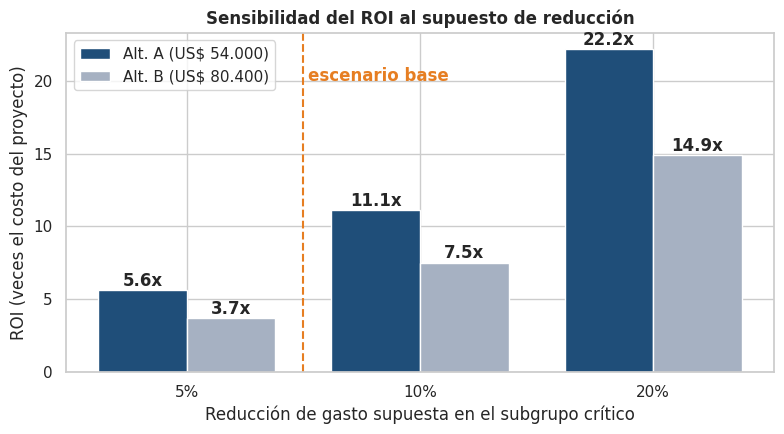

In [19]:
# Sensibilidad del ROI a la tasa de reducción de gasto supuesta
COSTO_ALT_A, COSTO_ALT_B = 54_000, 80_400

filas = []
for red in (0.05, 0.10, 0.20):
    ahorro = gasto_crit * red
    filas.append({
        'Reducción supuesta': f'{red:.0%}',
        'Ahorro anual (US$)': round(ahorro),
        'ROI Alt. A': round(ahorro / COSTO_ALT_A, 1),
        'ROI Alt. B': round(ahorro / COSTO_ALT_B, 1),
    })

sens = pd.DataFrame(filas).set_index('Reducción supuesta')
print('SENSIBILIDAD DEL ROI (cohorte de 1.338 afiliados)')
print('=' * 60)
print(sens.to_string())

base = sens.loc['10%']
print(f"\n>>> ESCENARIO BASE (10 %): ahorro US$ {base['Ahorro anual (US$)']:,.0f} "
      f"| ROI Alt. A {base['ROI Alt. A']}x | ROI Alt. B {base['ROI Alt. B']}x <<<")
print('\nNota: el ROI mide el ahorro contra el costo del proyecto analitico,')
print('no contra el costo del programa preventivo que genera ese ahorro.')

# Grafico de sensibilidad
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(sens))
ancho = 0.38
ax.bar(x - ancho/2, sens['ROI Alt. A'], ancho, label='Alt. A (US$ 54.000)', color=COL_PRIMARY, edgecolor='white')
ax.bar(x + ancho/2, sens['ROI Alt. B'], ancho, label='Alt. B (US$ 80.400)', color=COL_MUTED, edgecolor='white')
for i, (a, b) in enumerate(zip(sens['ROI Alt. A'], sens['ROI Alt. B'])):
    ax.text(i - ancho/2, a + 0.3, f'{a}x', ha='center', fontweight='bold')
    ax.text(i + ancho/2, b + 0.3, f'{b}x', ha='center', fontweight='bold')
ax.axvline(0.5, color=COL_ACCENT, linestyle='--', linewidth=1.5)
ax.text(0.52, max(sens['ROI Alt. A']) * 0.9, 'escenario base', color=COL_ACCENT, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(sens.index)
ax.set_xlabel('Reducción de gasto supuesta en el subgrupo crítico')
ax.set_ylabel('ROI (veces el costo del proyecto)')
ax.set_title('Sensibilidad del ROI al supuesto de reducción', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Conclusiones — validación del informe

| Afirmación del informe / presentación | Respaldo en este notebook | Valor calculado |
|---|---|---|
| 1.338 filas, 7 variables, 0 nulos | §1 | ✅ Verificado |
| Fumadores pagan 3,8× más | §3.1 | 3,80× |
| Fumador+obeso = US$ 41.693 | §4 | Confirmado |
| Southeast concentra mayor costo | §3.2 | US$ 14.735 |
| 20,5 % son fumadores | §5 | 20,48 % |
| 20 personas con IMC bajo (1,5 %) | §5 | 20 (1,49 %) |
| Correlaciones age 0,30, bmi 0,20 | §6 | Verificadas |
| Ser fumador aumenta charges ~US$ 23.848 (OLS) | §7 | Confirmado con p<0.001 |
| 10,8 % del padrón genera 33,8 % del gasto | §8 | 10,76 % / 33,81 % |
| ROI escenario base 10 % = 11,1x (Alt. A) | §8.1 | Sensibilidad 5/10/20 % |

**Conclusión metodológica:** los hallazgos que sustentan la recomendación (adoptar Alternativa A, focalizar prevención en el subgrupo fumador-obeso, restringir uso agregado por sesgos identificados) están respaldados por evidencia estadística **reproducible** en este notebook.

---

*Fin del anexo técnico. El notebook completo se puede ejecutar con `Kernel → Restart & Run All` en Jupyter.*